# Predictive Maintenance for Industrial Equipment Failure

## Exploratory Data Analysis (EDA) and Model Evaluation

**Project Type:** Binary Classification  
**Dataset:** Predictive Maintenance Dataset  
**Prepared by:** Amna Bibi  
**Team:** Baby Seven  
**Role:** Exploratory Data Analysis & Model Evaluation

---

### Project Objective

The objective of this project is to develop a predictive maintenance system that can identify whether an industrial equipment observation is associated with a machine failure.

The project follows a data science workflow consisting of:

1. Data loading and understanding
2. Data quality assessment
3. Exploratory Data Analysis (EDA)
4. Data preprocessing
5. Feature engineering
6. Machine learning classification
7. Model evaluation
8. Dashboard and deployment

This notebook focuses primarily on **Exploratory Data Analysis and Model Evaluation**.

## 1. Importing Required Libraries

The following Python libraries are used for data manipulation, numerical analysis, visualization, and statistical exploration.

- **Pandas:** Data loading, manipulation, and analysis
- **NumPy:** Numerical computations
- **Matplotlib:** Data visualization
- **Seaborn:** Statistical visualization
- **Warnings:** Suppression of non-critical warnings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading the Dataset

The cleaned predictive maintenance dataset prepared by the project team is loaded for exploratory analysis.

The dataset contains time information, equipment/device identifiers, a binary failure indicator, and multiple sensor measurements.

The target variable for the classification problem is:

- `failure = 0`: No failure
- `failure = 1`: Failure

In [2]:
df = pd.read_csv("../cleaned_predictive_maintenance_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (124493, 12)


,date,device,failure,Air_Temp_K,Process_Temp_K,Rotational_Speed,Torque,Tool_Wear,Pressure,Vibration,Voltage,Current
0,2015-01-01,S1F01085,0,215630672,55,0,52,6,407438,0,0,7
1,2015-01-01,W1F0Y13C,0,234318640,0,0,0,4,185772,0,0,3
2,2015-01-01,W1F0XKWR,0,89660704,0,0,0,7,30,0,0,0
3,2015-01-01,W1F0X7QX,0,162013456,0,0,0,12,217686,0,0,0
4,2015-01-01,W1F0X7PR,0,13138392,0,0,0,9,191343,0,0,0


## 3. Dataset Overview

Before performing statistical analysis, it is important to understand the structure and dimensions of the dataset.

The following analysis examines:

- Number of observations
- Number of variables
- Variable names
- Data types
- Initial records
- Summary statistics

Understanding the dataset structure helps identify suitable preprocessing and analysis techniques.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 124493
Number of columns: 12

Column names:
['date', 'device', 'failure', 'Air_Temp_K', 'Process_Temp_K', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'Pressure', 'Vibration', 'Voltage', 'Current']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124493 entries, 0 to 124492
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   date              124493 non-null  str  
 1   device            124493 non-null  str  
 2   failure           124493 non-null  int64
 3   Air_Temp_K        124493 non-null  int64
 4   Process_Temp_K    124493 non-null  int64
 5   Rotational_Speed  124493 non-null  int64
 6   Torque            124493 non-null  int64
 7   Tool_Wear         124493 non-null  int64
 8   Pressure          124493 non-null  int64
 9   Vibration         124493 non-null  int64
 10  Voltage           124493 non-null  int64
 11  Current           124493 non-null  int64
dtypes: int64(10), str(2)
memory usage: 11.4 MB


In [5]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,124493,304,2015-01-01,1163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device,124493,1169,W1F0JXDL,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
failure,124493.0,NaN,NaN,NaN,0.000851,0.029167,0.0,0.0,0.0,0.0,1.0
Air_Temp_K,124493.0,NaN,NaN,NaN,122387538.284345,70459335.225668,0.0,61283456.0,122797128.0,183309088.0,244140480.0
Process_Temp_K,124493.0,NaN,NaN,NaN,159.493988,2179.686488,0.0,0.0,0.0,0.0,64968.0
Rotational_Speed,124493.0,NaN,NaN,NaN,9.940977,185.748875,0.0,0.0,0.0,0.0,24929.0
Torque,124493.0,NaN,NaN,NaN,1.741134,22.908598,0.0,0.0,0.0,0.0,1666.0
Tool_Wear,124493.0,NaN,NaN,NaN,14.222719,15.943082,1.0,8.0,10.0,12.0,98.0
Pressure,124493.0,NaN,NaN,NaN,260173.031022,99151.389285,8.0,221452.0,249800.0,310266.0,689161.0
Vibration,124493.0,NaN,NaN,NaN,0.292531,7.436954,0.0,0.0,0.0,0.0,832.0


The sensor variables are retained using the project-defined feature names. Their numerical distributions are analyzed in the recorded scale without applying additional physical-unit assumptions."

## 4. Data Types

Examining data types is an important preprocessing and EDA step.

Numerical variables can be analyzed using statistical measures and numerical visualizations, while categorical variables require different analytical techniques.

The `date` variable will be converted into a datetime format to enable time-based analysis.

In [6]:
df.dtypes

date                  str
device                str
failure             int64
Air_Temp_K          int64
Process_Temp_K      int64
Rotational_Speed    int64
Torque              int64
Tool_Wear           int64
Pressure            int64
Vibration           int64
Voltage             int64
Current             int64
dtype: object

### Data Quality Analysis

##  Missing Value Analysis

Missing values can affect statistical analysis and machine learning performance.

The number and percentage of missing observations are therefore examined for each variable.

If missing values are present, their treatment should be documented in the preprocessing stage.

In [7]:
print("=== DATA QUALITY ANALYSIS ===")

print("\nMissing Values:")
display(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

=== DATA QUALITY ANALYSIS ===

Missing Values:


date                0
device              0
failure             0
Air_Temp_K          0
Process_Temp_K      0
Rotational_Speed    0
Torque              0
Tool_Wear           0
Pressure            0
Vibration           0
Voltage             0
Current             0
dtype: int64


Total Missing Values:
0

Duplicate Rows:
0

Data Types:
date                  str
device                str
failure             int64
Air_Temp_K          int64
Process_Temp_K      int64
Rotational_Speed    int64
Torque              int64
Tool_Wear           int64
Pressure            int64
Vibration           int64
Voltage             int64
Current             int64
dtype: object


##  Unique Value Analysis

The number of unique values in each variable is examined to understand the nature of the dataset and identify identifier-like variables or variables with limited categories.

In [8]:
print("=== UNIQUE VALUES ===")

unique_counts = df.nunique().sort_values()

display(unique_counts)

=== UNIQUE VALUES ===


failure                  2
Vibration               28
Voltage                 28
Rotational_Speed        48
Tool_Wear               60
Current                 67
Torque                 115
date                   304
Process_Temp_K         560
device                1169
Pressure             44838
Air_Temp_K          123877
dtype: int64

## 5. Date and Time Processing

The dataset contains a `date` variable representing the observation date.

Converting this variable to datetime format allows us to investigate temporal patterns in equipment failures, including failure frequency over time.

In [9]:
print("=== DATE CONTINUITY ANALYSIS ===")

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Sort by date
dates = df["date"].sort_values().drop_duplicates()

print("First Date:", dates.min())
print("Last Date:", dates.max())

print("Number of Unique Dates:", len(dates))

# Calculate gaps between consecutive calendar dates
date_gaps = dates.diff().dropna()

print("\nLargest Gap:")
print(date_gaps.max())

print("\nGap Distribution:")
print(date_gaps.value_counts().sort_index())

=== DATE CONTINUITY ANALYSIS ===
First Date: 2015-01-01 00:00:00
Last Date: 2015-11-02 00:00:00
Number of Unique Dates: 304

Largest Gap:
2 days 00:00:00

Gap Distribution:
date
1 days    301
2 days      2
Name: count, dtype: int64


In [10]:
print("=== MISSING CALENDAR DATES ===")

full_date_range = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D"
)

missing_dates = full_date_range.difference(dates)

print("Number of Missing Calendar Dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nMissing Dates:")
    for date in missing_dates:
        print(date.date())
else:
    print("✅ No calendar dates are missing.")

=== MISSING CALENDAR DATES ===
Number of Missing Calendar Dates: 2

Missing Dates:
2015-10-28
2015-11-01


In [11]:
print("=== DEVICE-LEVEL DATE GAP ANALYSIS ===")

device_dates = (
    df[["device", "date"]]
    .drop_duplicates()
    .sort_values(["device", "date"])
)

# Calculate gap between consecutive observations for each device
device_dates["gap_days"] = (
    device_dates.groupby("device")["date"]
    .diff()
    .dt.days
)

# Keep only gaps greater than 1 day
gaps = device_dates[device_dates["gap_days"] > 1]

print("Number of devices with gaps > 1 day:", gaps["device"].nunique())

print("Maximum device-level gap (days):", gaps["gap_days"].max())

print("\nDevice-level gap distribution:")
display(gaps["gap_days"].value_counts().sort_index())

=== DEVICE-LEVEL DATE GAP ANALYSIS ===
Number of devices with gaps > 1 day: 173
Maximum device-level gap (days): 143.0

Device-level gap distribution:


gap_days
2.0      65
3.0      32
4.0       1
9.0       2
10.0      1
11.0      4
14.0      8
16.0      1
18.0      3
20.0     10
21.0      1
22.0      1
23.0      4
24.0      4
28.0      2
29.0      9
30.0      3
35.0      2
37.0      1
38.0      1
42.0      1
43.0      1
44.0      1
45.0      1
48.0      2
49.0      3
50.0      2
51.0      1
53.0      1
57.0      1
58.0      6
59.0      1
60.0      1
63.0      1
64.0      1
66.0      1
67.0      1
71.0      2
78.0      2
79.0      1
81.0      2
105.0     1
106.0     2
112.0     1
113.0     4
114.0     1
115.0     1
119.0     1
120.0    16
123.0     2
125.0     1
133.0     1
143.0     1
Name: count, dtype: int64

In [12]:
print("=== OBSERVATIONS PER DEVICE ===")

device_observations = df.groupby("device")["date"].nunique()

display(device_observations.describe())

print("\nMinimum observations for a device:",
      device_observations.min())

print("Maximum observations for a device:",
      device_observations.max())

=== OBSERVATIONS PER DEVICE ===


count    1169.000000
mean      106.495295
std       102.651359
min         1.000000
25%         6.000000
50%        84.000000
75%       224.000000
max       304.000000
Name: date, dtype: float64


Minimum observations for a device: 1
Maximum observations for a device: 304


### Date Continuity and Gap Analysis

The `date` column was converted to datetime format and analyzed for temporal continuity.

The dataset spans from 2015-01-01 to 2015-11-02 and contains two missing calendar dates: 2015-10-28 and 2015-11-01.

Device-level analysis shows that observations are irregular across devices. A total of 173 devices have observation gaps greater than one day, with the maximum gap reaching 143 days. The number of observations per device also varies considerably, from 1 to 304 observations.

Therefore, the dataset should not be treated as a uniformly sampled time series. Missing dates were not filled, and sensor values were not interpolated or forward-filled because the missing observations cannot be reliably reconstructed. Artificially creating observations could introduce assumptions and distort the sensor-failure relationships.

The `date` column is retained as a datetime variable for temporal analysis and potential future feature engineering.

##  Target Variable Analysis

The target variable is `failure`, which represents whether an equipment failure occurred.

- `0` represents no failure.
- `1` represents failure.

Understanding the target distribution is essential because an imbalanced target can strongly affect classification model performance.

If failure observations are substantially fewer than non-failure observations, accuracy alone will not be a reliable measure of model performance.

In [13]:
print("=== FAILURE / TARGET ANALYSIS ===")

failure_counts = df["failure"].value_counts().sort_index()

print("Failure Counts:")
display(failure_counts)

print("\nFailure Percentages:")
failure_percentages = df["failure"].value_counts(normalize=True).sort_index() * 100
display(failure_percentages)

print("\nFailure Rate:")
print(f"{df['failure'].mean() * 100:.4f}%")

=== FAILURE / TARGET ANALYSIS ===
Failure Counts:


failure
0    124387
1       106
Name: count, dtype: int64


Failure Percentages:


failure
0    99.914855
1     0.085145
Name: proportion, dtype: float64


Failure Rate:
0.0851%


In [14]:
print("=== DEVICE-LEVEL FAILURE ANALYSIS ===")

failure_devices = df.loc[df["failure"] == 1, "device"].nunique()
total_devices = df["device"].nunique()

print("Total Devices:", total_devices)
print("Devices with at least one failure:", failure_devices)

print(
    "Percentage of devices with failure:",
    f"{failure_devices / total_devices * 100:.2f}%"
)

=== DEVICE-LEVEL FAILURE ANALYSIS ===
Total Devices: 1169
Devices with at least one failure: 106
Percentage of devices with failure: 9.07%


### Device-Level Failure Analysis

Although failure observations represent only 0.085% of all recorded observations, failures are distributed across 106 of the 1,169 devices in the dataset. This means approximately 9.07% of devices experienced at least one recorded failure.

The difference between the row-level failure rate (0.085%) and the device-level failure rate (9.07%) indicates that the extreme class imbalance is partly influenced by repeated observations from devices that did not experience failure.

This distinction is important when interpreting the dataset and evaluating predictive-maintenance models.

In [15]:
print("=== FAILURES PER DEVICE ===")

failures_per_device = (
    df[df["failure"] == 1]
    .groupby("device")
    .size()
    .sort_values(ascending=False)
)

print("Number of devices with failures:", len(failures_per_device))

print("\nFailures per affected device:")
display(failures_per_device.describe())

=== FAILURES PER DEVICE ===
Number of devices with failures: 106

Failures per affected device:


count    106.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
dtype: float64

### Failures per Device

The failure records were grouped by device to determine whether individual devices experienced multiple recorded failures. The analysis shows that all 106 devices with failures have exactly one recorded failure.

Therefore, the 106 failure observations correspond to 106 distinct devices. The remaining 1,063 devices have no recorded failure.

This indicates that, within the available observations, repeated failure events for the same device are not present. The extreme class imbalance therefore reflects the rarity of failure observations rather than multiple failure records being concentrated in a small number of devices.

Sensor cardinality & zero-value analysis

In [16]:
print("=== ZERO-VALUE ANALYSIS ===")

numeric_cols = df.select_dtypes(include=np.number).columns

zero_counts = (df[numeric_cols] == 0).sum()
zero_percentages = (df[numeric_cols] == 0).mean() * 100

zero_analysis = pd.DataFrame({
    "Zero_Count": zero_counts,
    "Zero_Percentage": zero_percentages
}).sort_values("Zero_Percentage", ascending=False)

display(zero_analysis)

=== ZERO-VALUE ANALYSIS ===


,Zero_Count,Zero_Percentage
failure,124387,99.914855
Vibration,123035,98.828850
Voltage,123035,98.828850
Process_Temp_K,118109,94.872001
Rotational_Speed,115358,92.662238
Torque,115155,92.499177
Current,97356,78.201987
Air_Temp_K,11,0.008836
Tool_Wear,0,0.000000
Pressure,0,0.000000


### Zero-Value Analysis

Several sensor variables contain a high proportion of zero values. However, the occurrence of zeros differs substantially between normal and failure observations.

Process_Temp_K, Torque, Vibration, and Voltage show notably lower zero percentages among failure observations than among normal observations. This indicates that zero versus non-zero status may contain useful information for distinguishing failure observations from normal observations.

Rotational_Speed and Current show smaller differences between the two failure classes, while Air_Temp_K, Tool_Wear, and Pressure contain almost no zero values.

The zero values were not treated as missing values because there is insufficient evidence that they represent missing measurements. Instead, their distribution was retained for further analysis and considered as a potentially informative characteristic of the sensor data.

In [17]:
print("=== ZERO VALUES BY FAILURE STATUS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

zero_by_failure = pd.DataFrame({
    "Normal_Zero_%": (df.loc[df["failure"] == 0, sensor_cols] == 0).mean() * 100,
    "Failure_Zero_%": (df.loc[df["failure"] == 1, sensor_cols] == 0).mean() * 100
})

display(zero_by_failure)

=== ZERO VALUES BY FAILURE STATUS ===


,Normal_Zero_%,Failure_Zero_%
Air_Temp_K,0.008843,0.000000
Process_Temp_K,94.906220,54.716981
Rotational_Speed,92.664828,89.622642
Torque,92.542629,41.509434
Tool_Wear,0.000000,0.000000
Pressure,0.000000,0.000000
Vibration,98.859206,63.207547
Voltage,98.859206,63.207547
Current,78.207530,71.698113


sensor distributions

=== SENSOR DISTRIBUTIONS ===


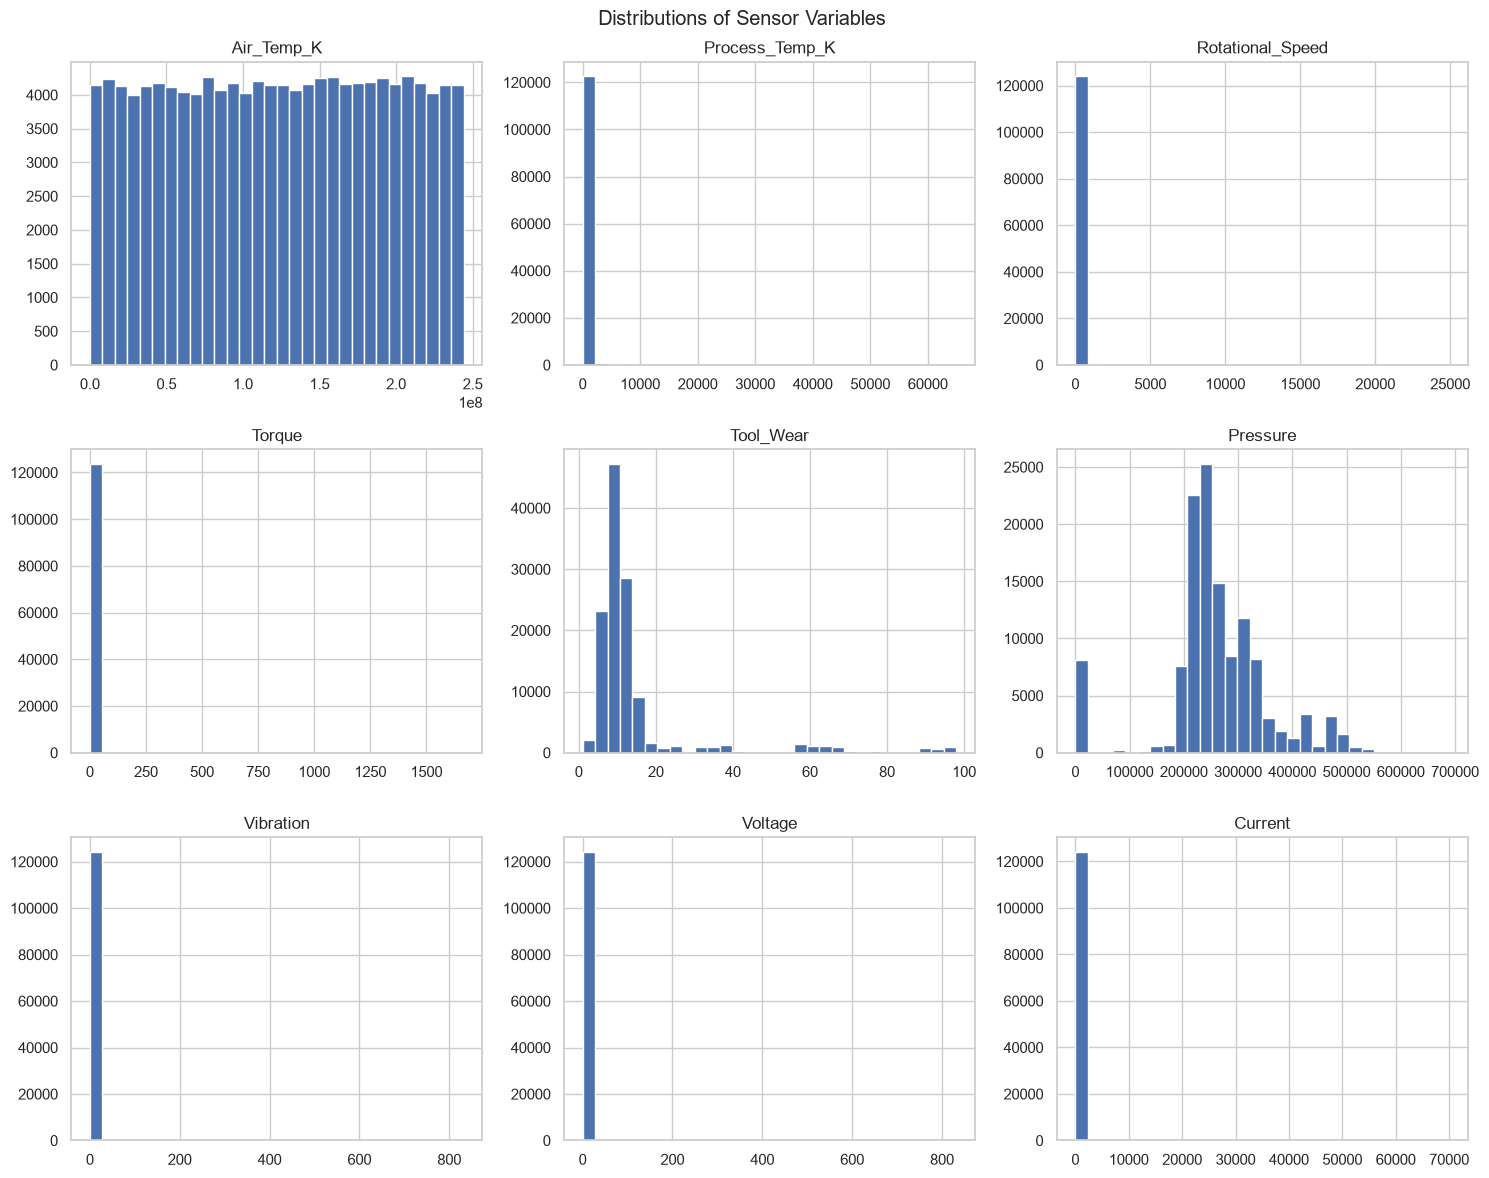

In [18]:
print("=== SENSOR DISTRIBUTIONS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

df[sensor_cols].hist(
    bins=30,
    figsize=(15, 12)
)

plt.suptitle("Distributions of Sensor Variables")
plt.tight_layout()
plt.show()

### Sensor Skewness Analysis

Skewness analysis shows that several sensor variables are strongly right-skewed. Current, Rotational_Speed, Vibration, Voltage, Torque, and Process_Temp_K have particularly high positive skewness.

This strong skewness is largely associated with the high proportion of zero values identified earlier, combined with a relatively small number of large observations.

Tool_Wear is also positively skewed, while Air_Temp_K is approximately symmetric and Pressure is only slightly left-skewed.

The skewed observations were not removed or transformed at this stage because high skewness does not necessarily indicate erroneous observations. The distributions will be further examined through outlier analysis and failure-group comparisons before deciding whether any preprocessing is appropriate.

In [19]:
print("=== SENSOR SKEWNESS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

skewness = df[sensor_cols].skew().sort_values(ascending=False)

display(skewness.to_frame(name="Skewness"))

=== SENSOR SKEWNESS ===


,Skewness
Current,148.164074
Rotational_Speed,82.710882
Vibration,73.476162
Voltage,73.476162
Torque,41.502446
Process_Temp_K,23.857228
Tool_Wear,3.483663
Air_Temp_K,-0.011127
Pressure,-0.375295


### Outlier Analysis

The Interquartile Range (IQR) method was used to identify statistically extreme observations. Air_Temp_K contained no observations outside the IQR boundaries, while Tool_Wear and Pressure contained approximately 11.36% and 11.56% IQR-based outliers, respectively.

For Process_Temp_K, Rotational_Speed, Torque, Vibration, Voltage, and Current, the IQR method produced zero as both the first and third quartile because these variables contain a very high proportion of zero values. Consequently, most or all non-zero observations are mathematically classified as IQR outliers.

These observations were not removed because they may represent legitimate operating or sensor states rather than data errors. In particular, extreme sensor readings may contain useful information for predictive-maintenance failure detection.

Therefore, IQR-based outlier flags are treated as descriptive information rather than an automatic basis for removing observations. Further analysis will compare sensor distributions between normal and failure observations before determining whether any preprocessing is necessary.

In [20]:
print("=== OUTLIER ANALYSIS (IQR METHOD) ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

outlier_results = []

for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_results.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Outlier_Percentage": outliers / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_results)

display(outlier_df)

=== OUTLIER ANALYSIS (IQR METHOD) ===


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Air_Temp_K,61283456.0,183309088.0,122025632.0,-121754992.0,366347536.0,0,0.000000
1,Process_Temp_K,0.0,0.0,0.0,0.0,0.0,6384,5.127999
2,Rotational_Speed,0.0,0.0,0.0,0.0,0.0,9135,7.337762
3,Torque,0.0,0.0,0.0,0.0,0.0,9338,7.500823
4,Tool_Wear,8.0,12.0,4.0,2.0,18.0,14141,11.358872
5,Pressure,221452.0,310266.0,88814.0,88231.0,443487.0,14392,11.560489
6,Vibration,0.0,0.0,0.0,0.0,0.0,1458,1.171150
7,Voltage,0.0,0.0,0.0,0.0,0.0,1458,1.171150
8,Current,0.0,0.0,0.0,0.0,0.0,27137,21.798013


### Sensor Zero-State and Failure Rate Analysis

Failure rates were compared between zero and non-zero sensor observations. Several variables show substantially higher failure rates when their recorded value is non-zero.

The strongest difference occurs for Vibration and Voltage. Their failure rate increases from approximately 0.054% for zero observations to 2.675% for non-zero observations. Process_Temp_K and Torque also show substantially higher failure rates for non-zero observations.

In contrast, Rotational_Speed and Current show relatively small differences between zero and non-zero states.

These results suggest that the zero/non-zero state of some sensor variables may contain predictive information. However, because the dataset contains only 106 failure observations, these findings are considered exploratory and should be validated during model training and evaluation.

In [21]:
print("=== SENSOR STATISTICS BY FAILURE STATUS ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

failure_stats = df.groupby("failure")[sensor_cols].agg(
    ["mean", "median", "min", "max"]
)

display(failure_stats)

=== SENSOR STATISTICS BY FAILURE STATUS ===


Air_Temp_K                                  Process_Temp_K         \
                 mean       median      min        max           mean median   
failure                                                                        
0        1.223835e+08  122785544.0        0  244140480     156.127931    0.0   
1        1.271755e+08  139117253.5  4527376  243261216    4109.433962    0.0   

                   Rotational_Speed         ... Vibration         Voltage  \
        min    max             mean median  ...       min  max       mean   
failure                                     ...                             
0         0  64968          9.94612    0.0  ...         0  832   0.266684   
1         0  64784          3.90566    0.0  ...         0  832  30.622642   

                           Current                    
        median min  max       mean median min    max  
failure                                               
0          0.0   0  832  13.005370    0.0   0  70000  
1          0.0   0  832  23.084906    0.0   0   1165  

[2 rows x 36 columns]

In [22]:
print("=== FAILURE RATE: ZERO VS NON-ZERO SENSOR VALUES ===")

sensor_cols = [
    "Air_Temp_K",
    "Process_Temp_K",
    "Rotational_Speed",
    "Torque",
    "Tool_Wear",
    "Pressure",
    "Vibration",
    "Voltage",
    "Current"
]

zero_nonzero_results = []

for col in sensor_cols:
    
    zero_mask = df[col] == 0
    nonzero_mask = df[col] != 0
    
    zero_failure_rate = df.loc[zero_mask, "failure"].mean() * 100
    nonzero_failure_rate = df.loc[nonzero_mask, "failure"].mean() * 100
    
    zero_nonzero_results.append({
        "Feature": col,
        "Zero_Count": zero_mask.sum(),
        "Nonzero_Count": nonzero_mask.sum(),
        "Failure_Rate_Zero_%": zero_failure_rate,
        "Failure_Rate_Nonzero_%": nonzero_failure_rate
    })

zero_nonzero_df = pd.DataFrame(zero_nonzero_results)

display(zero_nonzero_df)

=== FAILURE RATE: ZERO VS NON-ZERO SENSOR VALUES ===


,Feature,Zero_Count,Nonzero_Count,Failure_Rate_Zero_%,Failure_Rate_Nonzero_%
0,Air_Temp_K,11,124482,0.000000,0.085153
1,Process_Temp_K,118109,6384,0.049107,0.751880
2,Rotational_Speed,115358,9135,0.082352,0.120416
3,Torque,115155,9338,0.038209,0.663954
4,Tool_Wear,0,124493,NaN,0.085145
5,Pressure,0,124493,NaN,0.085145
6,Vibration,123035,1458,0.054456,2.674897
7,Voltage,123035,1458,0.054456,2.674897
8,Current,97356,27137,0.078064,0.110550


### Sensor Distributions by Failure Status

Sensor distributions were compared between normal and failure observations using summary statistics and boxplots.

Air_Temp_K shows a higher median among failure observations (139,117,253.5) than normal observations (122,785,544), although the overall ranges are similar.

Process_Temp_K shows a notable difference in its upper distribution. While the 25th, 50th, and 75th percentiles are all zero for normal observations, the 75th percentile for failure observations is 1,182. This is consistent with the earlier finding that non-zero Process_Temp_K observations have a higher failure rate.

Torque also shows a noticeable difference. Its median is zero for normal observations but 1.5 for failure observations, while the 75th percentile increases from zero to 18.75 for failure observations.

Vibration and Voltage show similar behavior. Their 75th percentile is zero for normal observations but 16 for failure observations, indicating a greater presence of non-zero values among failure observations.

Pressure has a higher median for failure observations (267,648.5) than normal observations (249,794), suggesting a potential difference in pressure distribution between the two classes.

Tool_Wear shows a relatively small difference, with the 75th percentile increasing from 12 for normal observations to 14 for failure observations. Current also shows a modest difference, with its 75th percentile increasing from zero to one among failure observations.

Rotational_Speed remains highly zero-inflated in both groups, with median and 75th percentile equal to zero. Its large maximum in the normal group also demonstrates that conventional boxplots can be difficult to interpret for highly zero-inflated variables.

Overall, Process_Temp_K, Torque, Vibration, Voltage, and Pressure show potentially informative differences between normal and failure observations. These patterns are exploratory and should be validated through appropriate model evaluation because the dataset contains only 106 failure observations.

=== SENSOR VALUES BY FAILURE STATUS ===


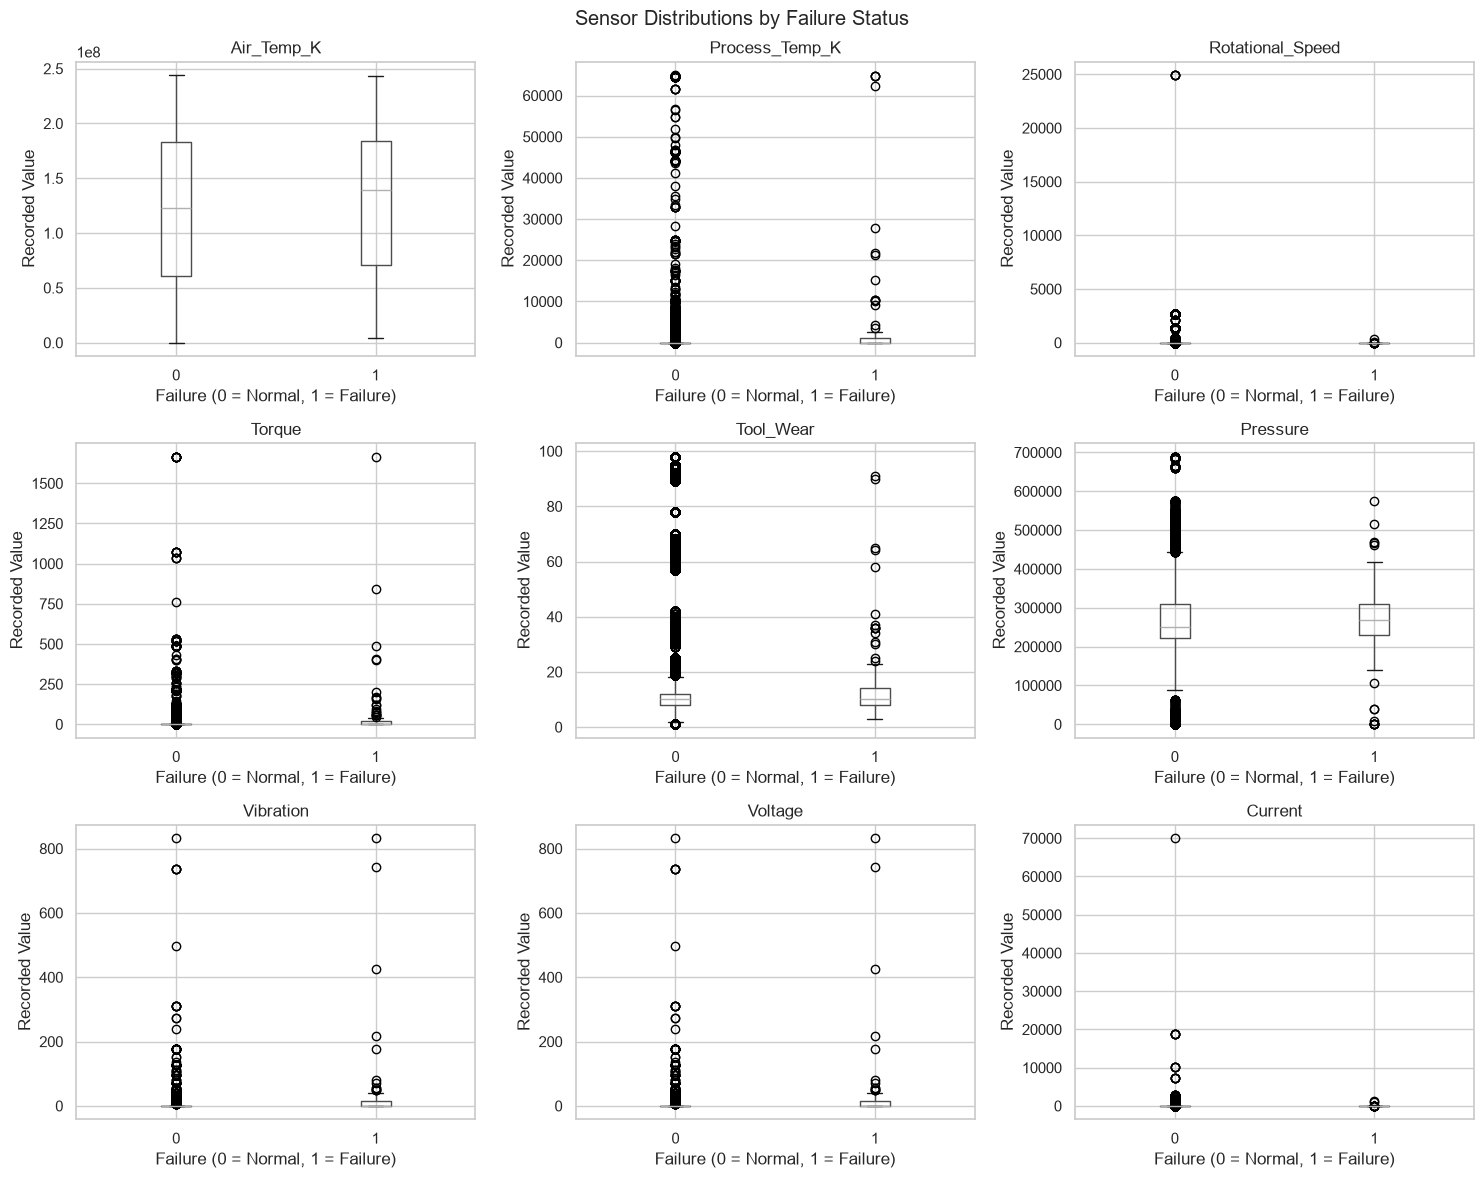

In [23]:
print("=== SENSOR VALUES BY FAILURE STATUS ===")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, col in zip(axes.flat, sensor_cols):
    df.boxplot(column=col, by="failure", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Failure (0 = Normal, 1 = Failure)")
    ax.set_ylabel("Recorded Value")

plt.suptitle("Sensor Distributions by Failure Status")
plt.tight_layout()
plt.show()

In [24]:
print("=== MEDIAN AND QUANTILE COMPARISON BY FAILURE ===")

comparison = df.groupby("failure")[sensor_cols].agg(
    ["median", "mean", "max"]
)

display(comparison)

=== MEDIAN AND QUANTILE COMPARISON BY FAILURE ===


Air_Temp_K                          Process_Temp_K               \
              median          mean        max         median         mean   
failure                                                                     
0        122785544.0  1.223835e+08  244140480            0.0   156.127931   
1        139117253.5  1.271755e+08  243261216            0.0  4109.433962   

               Rotational_Speed                 Torque  ... Pressure  \
           max           median     mean    max median  ...      max   
failure                                                 ...            
0        64968              0.0  9.94612  24929    0.0  ...   689161   
1        64784              0.0  3.90566    318    1.5  ...   574599   

        Vibration                 Voltage                 Current             \
           median       mean  max  median       mean  max  median       mean   
failure                                                                        
0             0.0   0.266684  832     0.0   0.266684  832     0.0  13.005370   
1             0.0  30.622642  832     0.0  30.622642  832     0.0  23.084906   

                
           max  
failure         
0        70000  
1         1165  

[2 rows x 27 columns]

In [25]:
print("=== SENSOR DISTRIBUTION BY FAILURE STATUS ===")

for col in sensor_cols:
    print(f"\n--- {col} ---")
    
    print("Normal (Failure = 0):")
    print(df.loc[df["failure"] == 0, col].describe()[["25%", "50%", "75%", "max"]])
    
    print("Failure (Failure = 1):")
    print(df.loc[df["failure"] == 1, col].describe()[["25%", "50%", "75%", "max"]])

=== SENSOR DISTRIBUTION BY FAILURE STATUS ===

--- Air_Temp_K ---
Normal (Failure = 0):
25%     61266484.0
50%    122785544.0
75%    183307652.0
max    244140480.0
Name: Air_Temp_K, dtype: float64
Failure (Failure = 1):


25%     70462350.0
50%    139117253.5
75%    183706600.0
max    243261216.0
Name: Air_Temp_K, dtype: float64

--- Process_Temp_K ---
Normal (Failure = 0):
25%        0.0
50%        0.0
75%        0.0
max    64968.0
Name: Process_Temp_K, dtype: float64
Failure (Failure = 1):
25%        0.0
50%        0.0
75%     1182.0
max    64784.0
Name: Process_Temp_K, dtype: float64

--- Rotational_Speed ---
Normal (Failure = 0):
25%        0.0
50%        0.0
75%        0.0
max    24929.0
Name: Rotational_Speed, dtype: float64
Failure (Failure = 1):
25%      0.0
50%      0.0
75%      0.0
max    318.0
Name: Rotational_Speed, dtype: float64

--- Torque ---
Normal (Failure = 0):
25%       0.0
50%       0.0
75%       0.0
max    1666.0
Name: Torque, dtype: float64
Failure (Failure = 1):
25%       0.00
50%       1.50
75%      18.75
max    1666.00
Name: Torque, dtype: float64

--- Tool_Wear ---
Normal (Failure = 0):
25%     8.0
50%    10.0
75%    12.0
max    98.0
Name: Tool_Wear, dtype: float64
Failure (Fa

### Redundant Feature Analysis

Vibration and Voltage were compared to determine whether they contain duplicate information. The two variables are exactly identical across all observations, with zero differing rows.

Therefore, Vibration and Voltage contain the same information and are redundant features. Keeping both variables would not provide additional predictive information and may introduce unnecessary duplication into the feature set.

For the EDA, both variables are retained for completeness and their identical behavior is documented. During model preprocessing, one of these two features can be removed to avoid redundancy.

In [26]:
print("=== REDUNDANT FEATURE CHECK ===")

print("Vibration and Voltage identical:",
      df["Vibration"].equals(df["Voltage"]))

print("Number of different rows:",
      (df["Vibration"] != df["Voltage"]).sum())

=== REDUNDANT FEATURE CHECK ===
Vibration and Voltage identical: True
Number of different rows: 0


### Correlation Analysis

Pearson correlation was calculated between the sensor variables and the failure target to examine their linear associations.

Vibration and Voltage have the strongest positive correlation with failure, with a correlation coefficient of approximately 0.119. This is followed by Torque (0.067) and Process_Temp_K (0.053).

Tool_Wear, Air_Temp_K, and Current have correlations very close to zero, indicating very weak linear associations with the failure target. Pressure and Rotational_Speed also have correlations close to zero, with slight negative values.

The identical correlation values for Vibration and Voltage are consistent with the earlier finding that these two variables contain exactly the same values across all observations.

The correlation results should be interpreted cautiously because Pearson correlation measures linear association and does not capture all possible nonlinear relationships. In addition, the dataset contains only 106 failure observations compared with 124,387 normal observations. Therefore, correlation alone should not be used to determine feature importance or remove variables.

In [27]:
print("=== CORRELATION WITH FAILURE ===")

correlation_with_failure = (
    df[sensor_cols + ["failure"]]
    .corr()["failure"]
    .drop("failure")
    .sort_values(ascending=False)
)

display(correlation_with_failure.to_frame(name="Correlation_with_Failure"))

=== CORRELATION WITH FAILURE ===


,Correlation_with_Failure
Vibration,0.119055
Voltage,0.119055
Torque,0.067398
Process_Temp_K,0.052901
Tool_Wear,0.002270
Air_Temp_K,0.001984
Current,0.001066
Pressure,-0.000550
Rotational_Speed,-0.000949


=== CORRELATION HEATMAP ===


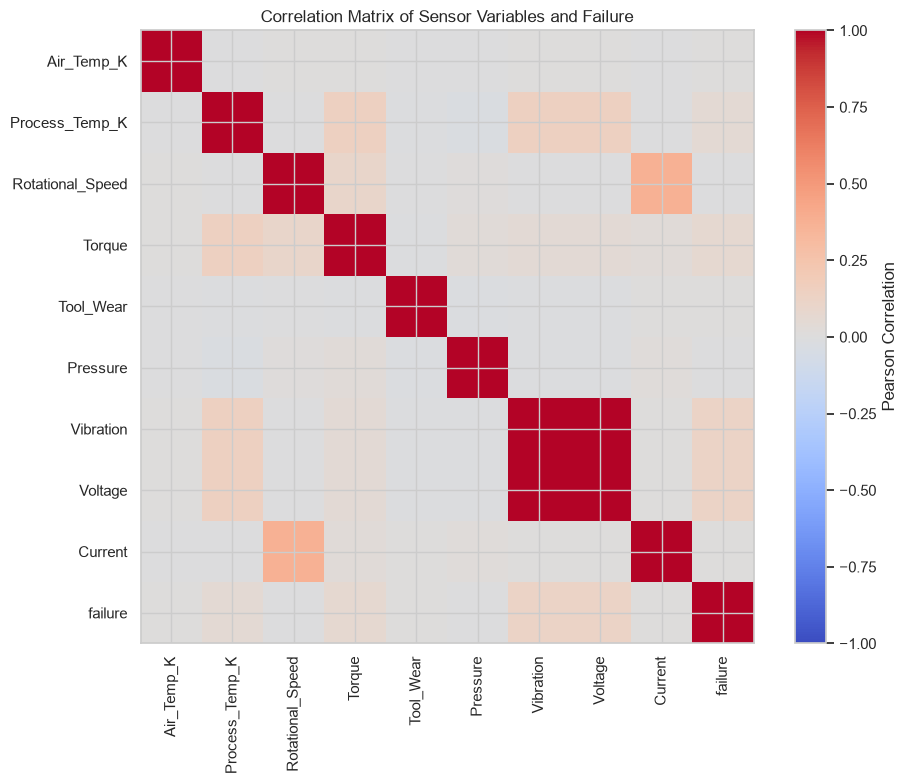

In [28]:
print("=== CORRELATION HEATMAP ===")

corr = df[sensor_cols + ["failure"]].corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Pearson Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix of Sensor Variables and Failure")

plt.tight_layout()
plt.show()

## EDA Findings and Conclusions

The exploratory data analysis revealed several important characteristics of the predictive-maintenance dataset.

### 1. Severe Class Imbalance

The dataset contains 124,493 observations, of which only 106 represent failure events. This corresponds to a failure rate of approximately 0.085%, indicating severe class imbalance. At the device level, 106 of 1,169 devices experienced at least one recorded failure.

This imbalance is an important consideration for model development and evaluation. Accuracy alone will not be an appropriate primary evaluation metric because a model could achieve very high accuracy by predicting the majority class.

### 2. Irregular Date Observations

The date analysis identified two calendar-level gaps, on 2015-10-28 and 2015-11-01. Device-level analysis also showed that 173 devices have observation gaps greater than one day, with the largest gap reaching 143 days.

The dataset therefore should not be assumed to represent a uniformly sampled time series. Missing dates were not artificially filled because there was insufficient information to reconstruct the missing observations reliably.

### 3. Zero-Inflated Sensor Variables

Several sensor variables contain a very high proportion of zero values, particularly Process_Temp_K, Rotational_Speed, Torque, Vibration, Voltage, and Current.

The zero/non-zero analysis showed that non-zero observations of Process_Temp_K, Torque, Vibration, and Voltage have higher observed failure rates than their zero-valued observations. This suggests that the zero/non-zero state may contain useful predictive information.

### 4. Sensor Distribution Differences

Comparison of sensor distributions between normal and failure observations revealed potentially informative differences. Process_Temp_K, Torque, Vibration, Voltage, and Pressure showed noticeable differences in their distributions between the two classes.

However, these observations are exploratory because the failure class contains only 106 observations.

### 5. Skewness and Outliers

Several variables exhibit strong right-skewness, particularly Current, Rotational_Speed, Vibration, Voltage, Torque, and Process_Temp_K. This behavior is largely associated with their high proportion of zero values and a smaller number of large observations.

The IQR method identified many statistical outliers in these zero-inflated variables. These observations were not removed because they may represent legitimate operating conditions or potentially informative failure-related measurements.

### 6. Feature Redundancy

Vibration and Voltage were found to be exactly identical across all 124,493 observations. Therefore, they contain redundant information. Both variables are retained in the EDA for documentation, while one can be removed during model preprocessing to avoid unnecessary duplication.

### 7. Correlation with Failure

Pearson correlation analysis identified Vibration and Voltage as having the strongest positive linear association with failure (approximately 0.119), followed by Torque (0.067) and Process_Temp_K (0.053).

The remaining variables showed very weak linear correlations with failure. However, low Pearson correlation does not necessarily mean that a variable has no predictive value because nonlinear relationships and interactions may exist.

### Overall EDA Conclusion

The dataset presents a challenging predictive-maintenance classification problem characterized by extreme class imbalance, irregular observation intervals, zero-inflated sensor variables, skewed distributions, potential outliers, and redundant features.

Vibration/Voltage, Torque, and Process_Temp_K show potentially useful relationships with failure, particularly through their zero/non-zero states and distributional differences.

These EDA findings will guide the subsequent preprocessing and model-evaluation stages. Because failures are extremely rare, model performance should be evaluated using metrics such as precision, recall, F1-score, PR-AUC, ROC-AUC, and the confusion matrix rather than relying on accuracy alone.